# Healthcare Prescription Safety & Patient Risk Intelligence Platform

## EDA & Statistics

### Purpose

Picking up from where I left off from Notebook 03, I sucessfully managed to export and merge dataset. 

In this notebook 03, I will dive deeper into EDA/visualizationa and statistics around four business questions: 

1. **Who are the highest-risk patients?** (age, diagnoses, admission history)
2. **Which patients are likely to be readmitted?**
3. **What medication safety risks exist?** (OpenFDA adverse event reports)
4. **Which diagnoses drive hospital utilization?** (chronic disease burden)


**Dataset**

From folder `Data/Processed/` (final clean version)


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

## 2. Load Data (clean version) 

In [2]:
PROCESSED = "../Data/Processed"

clinical_master = pd.read_csv(f"{PROCESSED}/clinical_master.csv")
diagnoses_clean = pd.read_csv(f"{PROCESSED}/diagnoses_clean.csv")
drug_events = pd.read_csv(f"{PROCESSED}/openfda_drug_events_long.csv")
med_ae_master = pd.read_csv(f"{PROCESSED}/med_adverse_event_master.csv")

print("clinical_master:", clinical_master.shape)
print("diagnoses_clean:", diagnoses_clean.shape)
print("drug_events:", drug_events.shape)
print("med_ae_master:", med_ae_master.shape)

clinical_master: (275, 24)
diagnoses_clean: (4506, 7)
drug_events: (265, 5)
med_ae_master: (875, 20)


## 3. Business Q1 — Who are the highest-risk patients?

**Three Factors : `age`, `diagnosis burden`, and `admission history`.**

In [3]:
patient_summary = clinical_master.groupby("subject_id").agg(
    age=("anchor_age", "first"),
    gender=("gender", "first"),
    deceased=("deceased", "first"),
    total_admissions=("hadm_id", "count"),
    total_diagnoses=("diagnosis_count", "sum"),
    avg_length_of_stay=("length_of_stay_days", "mean"),
    ever_readmitted_30d=("readmitted_30d", "max"),
).reset_index()

patient_summary["avg_length_of_stay"] = patient_summary["avg_length_of_stay"].round(1)

print(patient_summary.shape)
patient_summary.head()

(100, 8)


,subject_id,age,gender,deceased,total_admissions,total_diagnoses,avg_length_of_stay,ever_readmitted_30d
0,10000032,52,F,1,4,39,1.4,1
1,10001217,55,F,0,2,17,6.4,1
2,10001725,46,F,0,1,18,3.0,0
3,10002428,80,F,0,7,114,5.6,1
4,10002495,81,M,0,1,26,6.9,0


**Flag Patient as High Risk** based on the following condition: `3+ admissions` or at `one 30-day readmission`.

In [4]:
patient_summary["high_risk"] = (
    (patient_summary["total_admissions"] >= 3) | (patient_summary["ever_readmitted_30d"] == 1)
).astype(int)

print(f"High-risk patients: {patient_summary['high_risk'].sum()} of {len(patient_summary)} "
      f"({patient_summary['high_risk'].mean():.1%})")

patient_summary.sort_values("total_admissions", ascending=False).head(10)

High-risk patients: 35 of 100 (35.0%)


,subject_id,age,gender,deceased,total_admissions,total_diagnoses,avg_length_of_stay,ever_readmitted_30d,high_risk
35,10014354,60,M,0,20,447,4.2,1,1
38,10015860,53,M,0,13,208,6.3,0,1
5,10002930,48,F,1,12,109,3.3,1,1
99,10040025,64,F,1,10,259,6.6,1,1
96,10039708,46,F,0,10,198,7.5,1,1
90,10037928,78,F,0,10,169,4.1,0,1
87,10035631,63,M,1,9,136,13.2,1,1
49,10019003,65,F,1,8,171,7.7,1,1
3,10002428,80,F,0,7,114,5.6,1,1
7,10003400,72,F,1,7,153,11.7,1,1


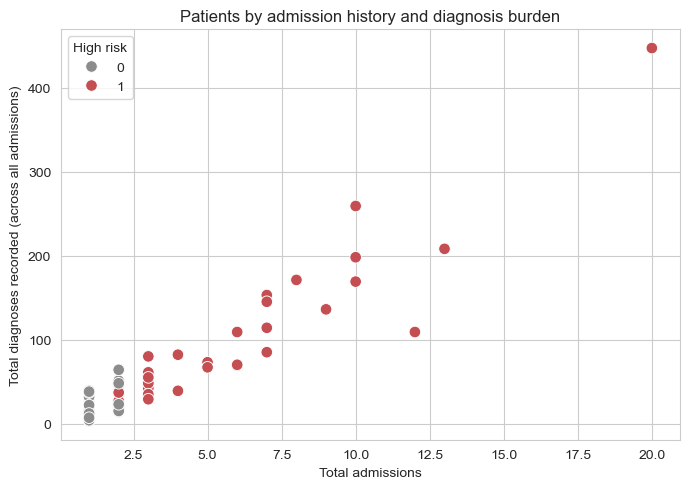

In [5]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=patient_summary,
    x="total_admissions",
    y="total_diagnoses",
    hue="high_risk",
    palette={0: "#8C8C8C", 1: "#C44E52"},
    s=70,
)
plt.title("Patients by admission history and diagnosis burden")
plt.xlabel("Total admissions")
plt.ylabel("Total diagnoses recorded (across all admissions)")
plt.legend(title="High risk")
plt.tight_layout()
plt.show()

Findings: High-risk patients(red) cluster toward more admissions and diagnoses. 

## 4. Q2 — Which patients are likely to be readmitted?

Notebook 03 the results showed group by age (<30), gender(Female), insurance(Medicaid) and admission type(direct emergency

So I will perform a **t-test** to compare the *average* of a numeric variable (age, length of stay, diagnosis count) between the readmitted and not-readmitted groups. **p-value** is the probability of seeing a difference this large by chance alone if there were truly no difference — the usual cutoff is 0.05: below that, I can call it "statistically significant".

In [6]:
readmit_adm = clinical_master[clinical_master["readmitted_30d"] == 1]
not_readmit_adm = clinical_master[clinical_master["readmitted_30d"] == 0]

def compare(col, label):
    t, p = stats.ttest_ind(readmit_adm[col], not_readmit_adm[col], equal_var=False, nan_policy="omit")
    sig = "significant (p < 0.05)" if p < 0.05 else "not significant"
    print(f"{label:22s} readmitted mean={readmit_adm[col].mean():6.1f}   "
          f"not-readmitted mean={not_readmit_adm[col].mean():6.1f}   p={p:.3f}  -> {sig}")

compare("anchor_age", "Age")
compare("length_of_stay_days", "Length of stay")
compare("diagnosis_count", "Diagnosis count")

Age                    readmitted mean=  58.3   not-readmitted mean=  61.7   p=0.102  -> not significant
Length of stay         readmitted mean=   7.6   not-readmitted mean=   6.7   p=0.342  -> not significant
Diagnosis count        readmitted mean=  18.0   not-readmitted mean=  16.0   p=0.154  -> not significant


I will also perform a **Chi-square test** which fit best a *categorical* variable and check if `admission_type`and `30-day readmission`are related. 

In [7]:
ct = pd.crosstab(clinical_master["admission_type"], clinical_master["readmitted_30d"])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)

sig = "significant (p < 0.05)" if p_chi < 0.05 else "not significant"
print(f"admission_type vs readmitted_30d:  chi2={chi2:.2f}, p={p_chi:.3f}  -> {sig}")
ct

admission_type vs readmitted_30d:  chi2=8.31, p=0.404  -> not significant


readmitted_30d,0,1
admission_type,,
AMBULATORY OBSERVATION,5,0
DIRECT EMER.,10,5
DIRECT OBSERVATION,6,1
ELECTIVE,11,2
EU OBSERVATION,28,2
EW EMER.,79,25
OBSERVATION ADMIT,36,9
SURGICAL SAME DAY ADMISSION,15,3
URGENT,32,6


Findings: Both the t-test and Chi-square test comes back not significant due to the limited size of the dataset (only 275 admissions and readmission is also a minority outcome) 

## 5. Q3 — What medication safety risks exist?

Notebook 03 ranked medications by *count* (Prednisone, Letairis & Casodex) of adverse-events reports is different from computing each medication's **serious-event rate**: and report that were flagged serious.

In [8]:
serious_ids = (
    med_ae_master.loc[med_ae_master["serious"] == "Yes", ["medicinalproduct", "safetyreportid"]]
    .drop_duplicates()
)
serious_counts = serious_ids.groupby("medicinalproduct").size().rename("serious_reports")

med_stats = drug_events.groupby("medicinalproduct")["safetyreportid"].nunique().rename("total_reports").to_frame()
med_stats = med_stats.join(serious_counts).fillna({"serious_reports": 0})
med_stats["serious_reports"] = med_stats["serious_reports"].astype(int)
med_stats["serious_rate"] = (med_stats["serious_reports"] / med_stats["total_reports"]).round(2)

top_meds = med_stats[med_stats["total_reports"] >= 2].sort_values(
    ["serious_rate", "total_reports"], ascending=False
)
top_meds.head(10)

,total_reports,serious_reports,serious_rate
medicinalproduct,,,
PREDNISONE,7,7,1.0
AMLODIPINE,2,2,1.0
AZATHIOPRINE,2,2,1.0
BENLYSTA,2,2,1.0
CYCLOPHOSPHAMIDE,2,2,1.0
CYMBALTA,2,2,1.0
IBUPROFEN,2,2,1.0
METHOTREXATE,2,2,1.0
MIRENA,2,2,1.0


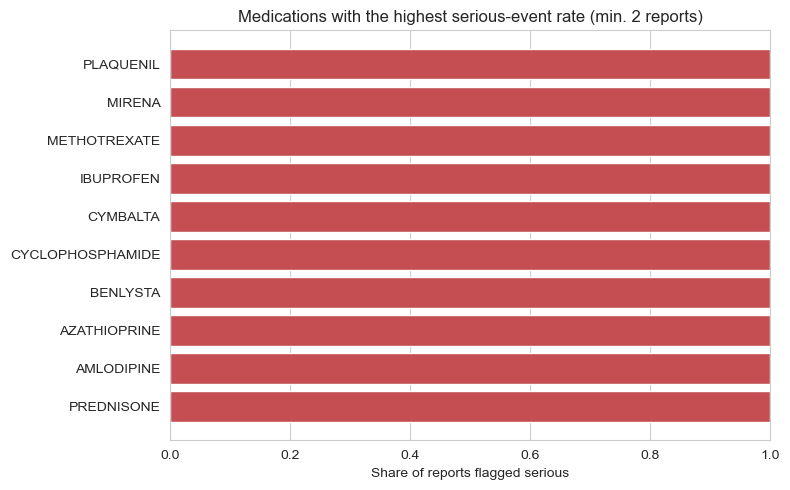

In [9]:
top10 = top_meds.head(10).sort_values("serious_rate")

plt.figure(figsize=(8, 5))
plt.barh(top10.index, top10["serious_rate"], color="#C44E52")
plt.xlabel("Share of reports flagged serious")
plt.title("Medications with the highest serious-event rate (min. 2 reports)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

**IMPORTANT NOTE** This data is from OpenFDA sample (public feed) not linked to the MIMIC patients. In order to connect the two we would need *`real prescriptions`* with the *`patient ID`*. 

## 6. Q4 — Which diagnoses drive hospital utilization?

`Utilization` correspond to patient using hospital resource by lenght of stay, number of diagnoses reported, how often they come back. 

*`Hypothesis`* Do patient carrying a **chronic condition** (such as diabetes or hypertension) use more than patient with only acute or one-off diagnose)


In [10]:
CHRONIC_LABELS = {
    "Hypertension", "Hyperlipidemia", "Hypothyroidism", "Atrial fibrillation",
    "Type 2 diabetes", "Coronary artery disease", "GERD",
    "Long-term drug therapy (insulin)", "Long-term anticoagulant use",
    "Coronary atherosclerosis (native artery)", "Coronary artery disease with angina",
}

diagnoses_clean["is_chronic"] = diagnoses_clean["diagnosis_label"].isin(CHRONIC_LABELS)
chronic_flag = (
    diagnoses_clean.groupby("hadm_id")["is_chronic"].any()
    .rename("has_chronic_condition")
    .reset_index()
)

cm2 = clinical_master.merge(chronic_flag, on="hadm_id", how="left")
cm2["has_chronic_condition"] = cm2["has_chronic_condition"].fillna(False)

print(f"Admissions involving a chronic condition: {cm2['has_chronic_condition'].sum()} of {len(cm2)} "
      f"({cm2['has_chronic_condition'].mean():.1%})")

cm2.groupby("has_chronic_condition")[["length_of_stay_days", "diagnosis_count", "prior_admissions_count"]].mean().round(2)


Admissions involving a chronic condition: 207 of 275 (75.3%)


,length_of_stay_days,diagnosis_count,prior_admissions_count
has_chronic_condition,,,
False,6.39,11.04,2.26
True,7.04,18.14,2.84


Admissions involving a chronic condition run noticeably higher on all three utilization measures. 

A **correlation matrix** checks this more directly across all the numeric features at once (values closer to *`1`* or *`-1`* mean two variables move together more strongly).

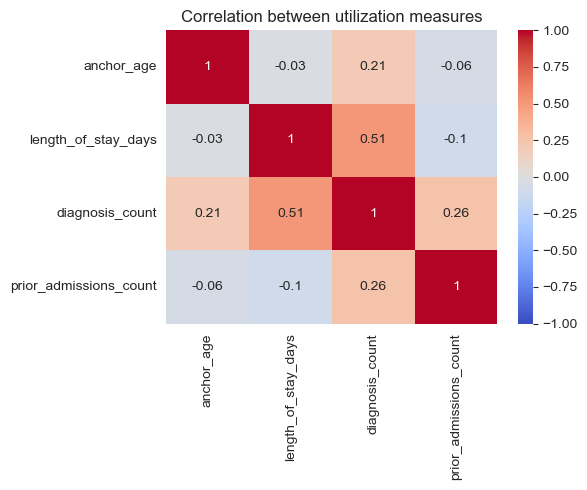

In [11]:
corr_cols = ["anchor_age", "length_of_stay_days", "diagnosis_count", "prior_admissions_count"]
corr = cm2[corr_cols].corr().round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation between utilization measures")
plt.tight_layout()
plt.show()

**Findings:** 
- `diagnosis_count` and `length_of_stay_days` have the strongest relationship (0.51)
- **admissions** with more recorded diagnoses tend to run longer, which lines up with the chronic-condition comparison above.
- **Age** barely correlates with any of these, suggesting **diagnosis burden** (not age alone) is the better predictor of utilization in this cohort.

## 7 RECAP 


- **`Business Q1`** : `Highest risk patient` -> High-risk patients: 35 of 100 (35.0%)

- **`Business Q2`** : `Readmission` -> inconclusive age, LOS, diagnosis count or admission type are not statistically significant at this sample size (275 admissions)in this dataset I can't confirm it.

- **`Business Q3`** : `Medication safety` -> Ranking by *serious-event rate* demonstrated to be more useful list rsiky medications than notebook 03 raw counts. 

- **`Business Q4`** : `Utilization` -> Admissions involving a chronic condition: 207 of 275 (75.3%) and diagnosis count correlates with lenght of stay(r=0.51) more than age does.